# 第24章: クラスター分析

## 学習目標
- K-means法を理解し適用できる
- 階層的クラスタリングを実行できる
- デンドログラムを作成・解釈できる
- シルエット係数を計算できる
- クラスター数の選択ができる

## 📋 学習メタ情報

### 推定学習時間
**100〜130分**

### 難易度
**★★★☆☆** (5段階中3)

---

## 🎯 なぜこの章を学ぶのか？

この章の内容は、実務での統計的データ分析に直結する重要なトピックです。理論と実践の両面から理解を深めましょう。

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 24.1 クラスター分析の概要

### 定義
類似した観測値をグループ（クラスター）に分ける教師なし学習手法

### クラスタリング手法の分類
1. **分割型**: K-means, K-medoids
2. **階層型**: 凝集型、分割型
3. **密度ベース**: DBSCAN
4. **モデルベース**: 混合ガウスモデル

クラスター分析の基本概念

サンプル数: 300
クラスター数: 3


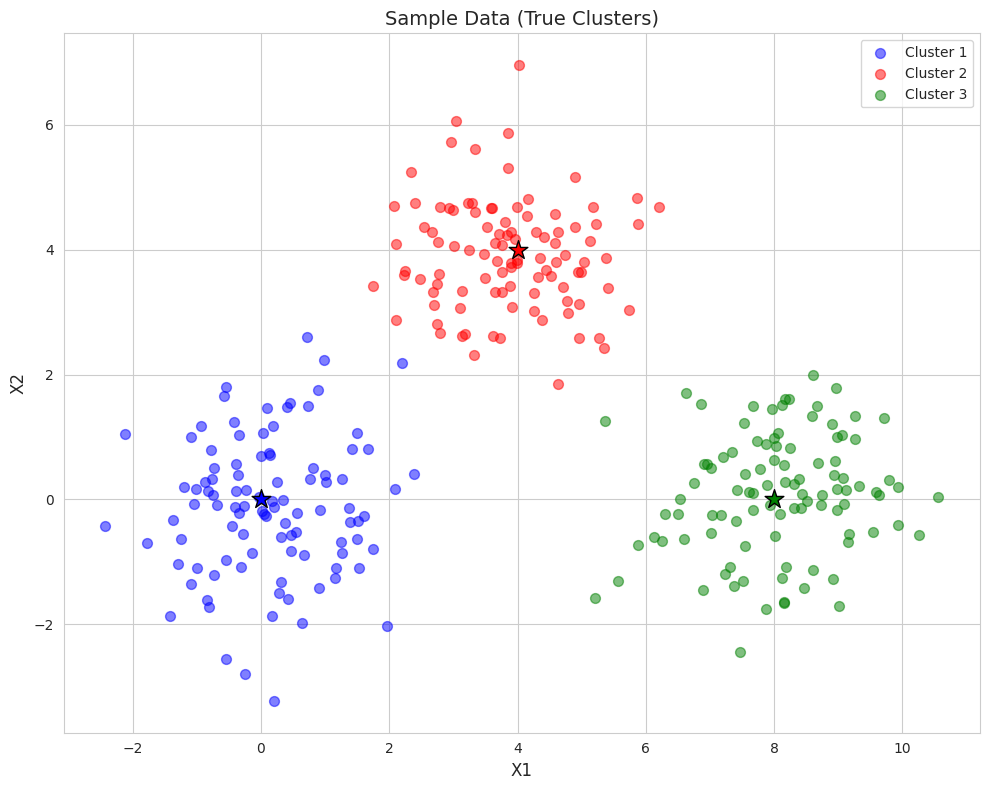

In [2]:
# サンプルデータの生成
np.random.seed(123)

# Generate 3 clusters
n_per_cluster = 100
centers = [[0, 0], [4, 4], [8, 0]]

X = []
y_true = []

for i, center in enumerate(centers):
    cluster = np.random.randn(n_per_cluster, 2) + center
    X.append(cluster)
    y_true.extend([i] * n_per_cluster)

X = np.vstack(X)
y_true = np.array(y_true)

print("クラスター分析の基本概念")
print("="*50)
print(f"\nサンプル数: {len(X)}")
print(f"クラスター数: {len(centers)}")

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['blue', 'red', 'green']
for i in range(3):
    mask = y_true == i
    ax.scatter(X[mask, 0], X[mask, 1], c=colors[i], alpha=0.5, 
               label=f'Cluster {i+1}', s=50)
    ax.scatter(*centers[i], c=colors[i], s=200, marker='*', edgecolor='black')

ax.set_xlabel('X1', fontsize=12)
ax.set_ylabel('X2', fontsize=12)
ax.set_title('Sample Data (True Clusters)', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

## 24.2 K-meansクラスタリング

### アルゴリズム
1. $K$ 個の初期中心を選択
2. 各点を最も近い中心に割り当て
3. 各クラスターの中心を更新
4. 収束するまで2-3を繰り返す

### 目的関数
クラスター内平方和 (WCSS) を最小化:
$$J = \sum_{k=1}^{K} \sum_{i \in C_k} ||\mathbf{x}_i - \boldsymbol{\mu}_k||^2$$

### 特徴
- 計算が高速
- 球状のクラスターを仮定
- 初期値に依存

In [3]:
# K-meansアルゴリズムの可視化
def kmeans_step_by_step(X, K, max_iter=10):
    """Visualize K-means algorithm step by step."""
    n = len(X)
    
    # Random initialization
    idx = np.random.choice(n, K, replace=False)
    centroids = X[idx].copy()
    
    history = [centroids.copy()]
    
    for iteration in range(max_iter):
        # Assign points to nearest centroid
        distances = np.sqrt(((X[:, np.newaxis] - centroids)**2).sum(axis=2))
        labels = np.argmin(distances, axis=1)
        
        # Update centroids
        new_centroids = np.array([X[labels == k].mean(axis=0) for k in range(K)])
        
        # Check convergence
        if np.allclose(centroids, new_centroids):
            break
        
        centroids = new_centroids
        history.append(centroids.copy())
    
    return labels, centroids, history

# Run K-means
np.random.seed(456)
K = 3
labels, centroids, history = kmeans_step_by_step(X, K)

print("K-meansクラスタリング")
print("="*50)
print(f"\n反復回数: {len(history)}")
print(f"\n最終中心:")
for i, c in enumerate(centroids):
    print(f"  Cluster {i+1}: {c}")

K-meansクラスタリング

反復回数: 6

最終中心:
  Cluster 1: [ 7.26385094 -0.67042591]
  Cluster 2: [8.38630354 0.85916498]
  Cluster 3: [1.89135366 1.84946373]


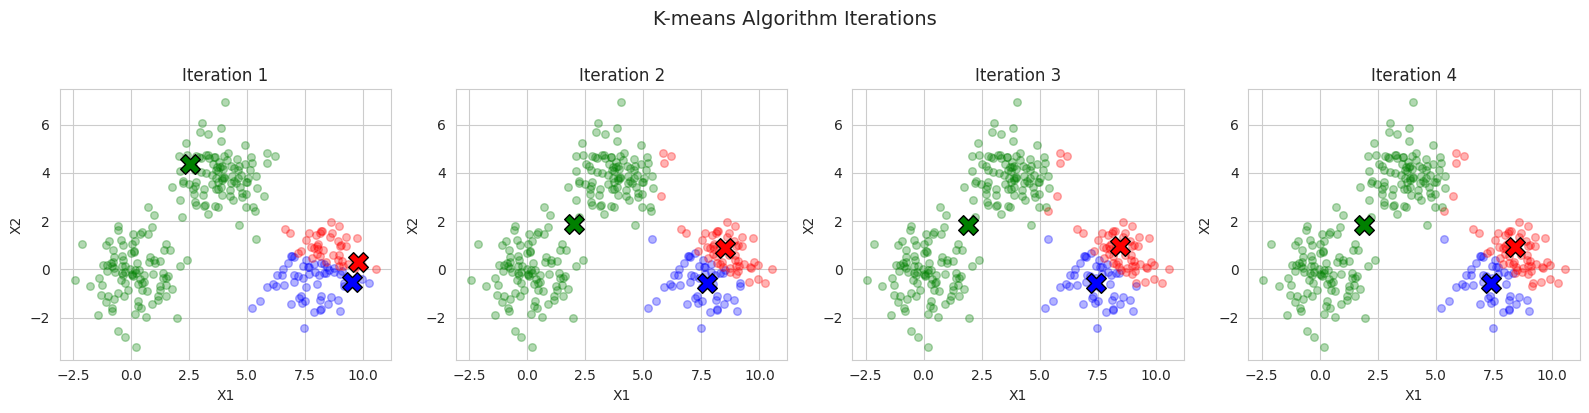

In [4]:
# Visualize K-means iterations
n_steps = min(4, len(history))
fig, axes = plt.subplots(1, n_steps, figsize=(4*n_steps, 4))

colors = ['blue', 'red', 'green']

for idx, ax in enumerate(axes):
    if idx < len(history):
        # Calculate labels for this iteration
        cent = history[idx]
        distances = np.sqrt(((X[:, np.newaxis] - cent)**2).sum(axis=2))
        labs = np.argmin(distances, axis=1)
        
        # Plot points
        for k in range(K):
            mask = labs == k
            ax.scatter(X[mask, 0], X[mask, 1], c=colors[k], alpha=0.3, s=30)
        
        # Plot centroids
        for k in range(K):
            ax.scatter(*cent[k], c=colors[k], s=200, marker='X', edgecolor='black')
        
        ax.set_title(f'Iteration {idx+1}', fontsize=12)
        ax.set_xlabel('X1')
        ax.set_ylabel('X2')

plt.suptitle('K-means Algorithm Iterations', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


sklearnによるK-means:
WCSS (Inertia): 591.87

中心:
  Cluster 1: [3.831, 3.907]
  Cluster 2: [8.055, 0.081]
  Cluster 3: [0.110, -0.147]


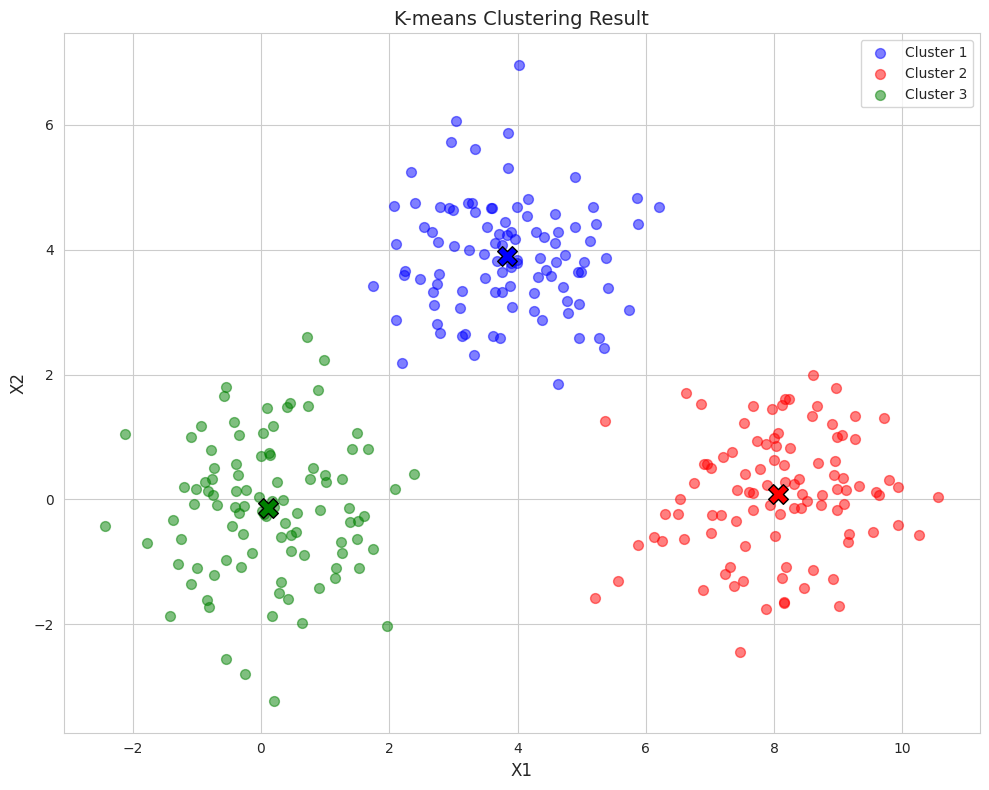

In [5]:
# Using sklearn
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

print("\nsklearnによるK-means:")
print(f"WCSS (Inertia): {kmeans.inertia_:.2f}")
print(f"\n中心:")
for i, c in enumerate(kmeans.cluster_centers_):
    print(f"  Cluster {i+1}: [{c[0]:.3f}, {c[1]:.3f}]")

# Plot result
fig, ax = plt.subplots(figsize=(10, 8))
for k in range(3):
    mask = y_kmeans == k
    ax.scatter(X[mask, 0], X[mask, 1], c=colors[k], alpha=0.5, 
               label=f'Cluster {k+1}', s=50)
    ax.scatter(*kmeans.cluster_centers_[k], c=colors[k], s=200, 
               marker='X', edgecolor='black')

ax.set_xlabel('X1', fontsize=12)
ax.set_ylabel('X2', fontsize=12)
ax.set_title('K-means Clustering Result', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

## 24.3 階層的クラスタリング

### 凝集型（ボトムアップ）
1. 各点を個別のクラスターとする
2. 最も近いクラスターのペアを結合
3. 1つのクラスターになるまで繰り返す

### 結合方法
- **単連結法 (single)**: クラスター間の最小距離
- **完全連結法 (complete)**: クラスター間の最大距離
- **群平均法 (average)**: クラスター間の平均距離
- **ウォード法 (ward)**: クラスター内分散の増加を最小化

In [6]:
# 階層的クラスタリング
print("階層的クラスタリング")
print("="*60)

# Calculate linkage for different methods
methods = ['single', 'complete', 'average', 'ward']
linkages = {}

for method in methods:
    linkages[method] = linkage(X, method=method)
    print(f"\n{method}法:")
    print(f"  最終結合距離: {linkages[method][-1, 2]:.3f}")

階層的クラスタリング

single法:
  最終結合距離: 1.326

complete法:
  最終結合距離: 12.995

average法:
  最終結合距離: 6.976

ward法:
  最終結合距離: 73.084


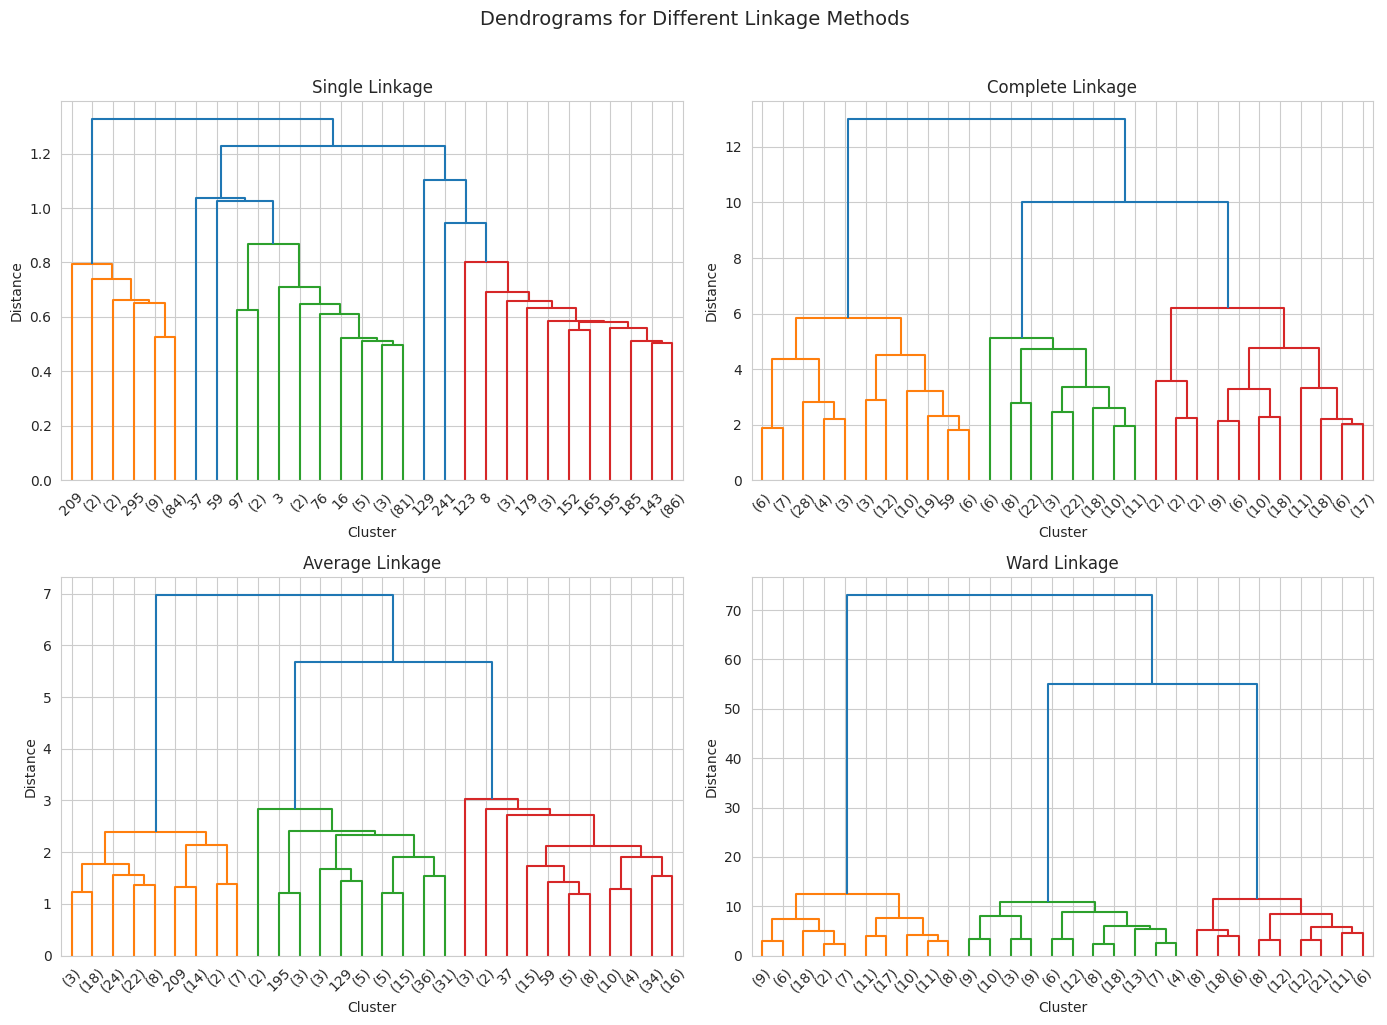

In [7]:
# Compare dendrograms
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, method in zip(axes.flat, methods):
    dendrogram(linkages[method], ax=ax, truncate_mode='lastp', p=30,
               show_leaf_counts=True)
    ax.set_title(f'{method.capitalize()} Linkage', fontsize=12)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Distance')

plt.suptitle('Dendrograms for Different Linkage Methods', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

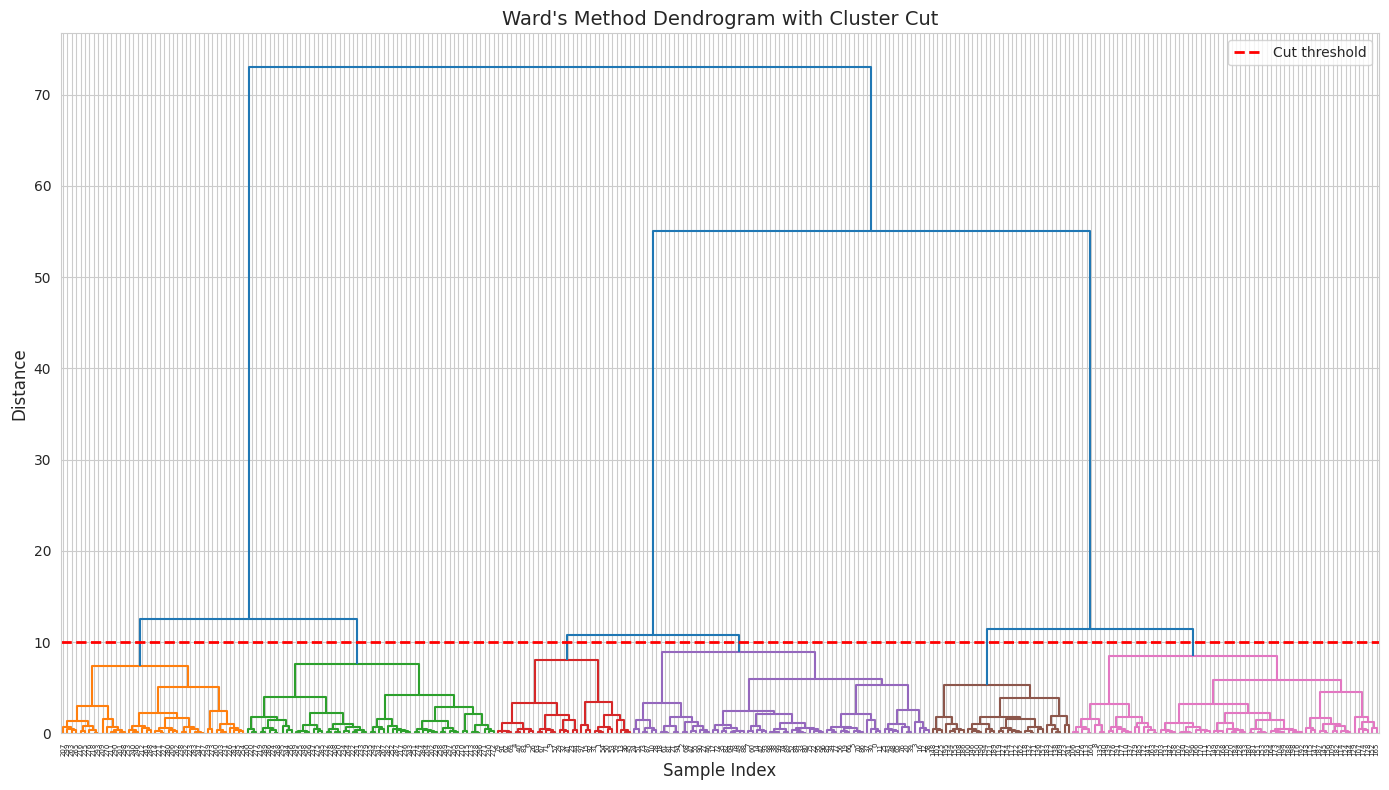


Ward法によるクラスター割り当て (K=3):
各クラスターのサンプル数: [np.int64(99), np.int64(99), np.int64(102)]


In [8]:
# Ward's method dendrogram with cluster cut
fig, ax = plt.subplots(figsize=(14, 8))

dendrogram(linkages['ward'], ax=ax, color_threshold=10)
ax.axhline(y=10, color='r', linestyle='--', linewidth=2, label='Cut threshold')
ax.set_xlabel('Sample Index', fontsize=12)
ax.set_ylabel('Distance', fontsize=12)
ax.set_title("Ward's Method Dendrogram with Cluster Cut", fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

# Get cluster assignments
y_ward = fcluster(linkages['ward'], t=3, criterion='maxclust')
print(f"\nWard法によるクラスター割り当て (K=3):")
print(f"各クラスターのサンプル数: {[np.sum(y_ward == k) for k in range(1, 4)]}")

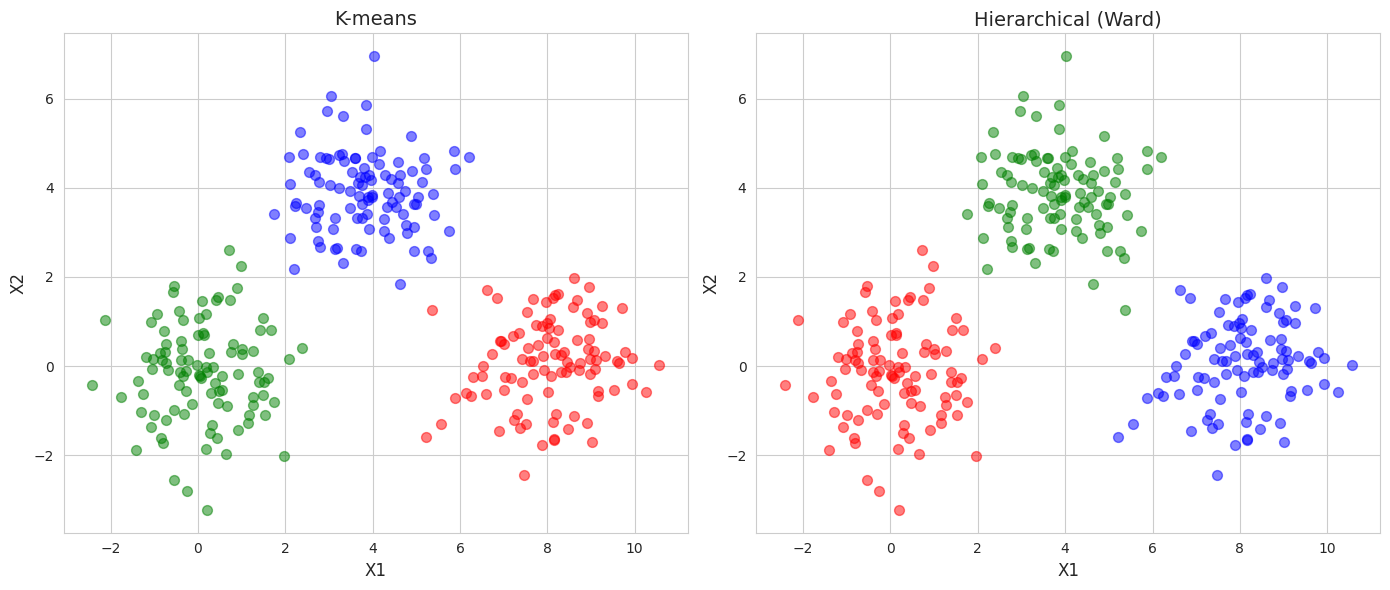

In [9]:
# Compare clustering results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-means
for k in range(3):
    mask = y_kmeans == k
    axes[0].scatter(X[mask, 0], X[mask, 1], c=colors[k], alpha=0.5, s=50)
axes[0].set_xlabel('X1', fontsize=12)
axes[0].set_ylabel('X2', fontsize=12)
axes[0].set_title('K-means', fontsize=14)

# Hierarchical (Ward)
for k in range(1, 4):
    mask = y_ward == k
    axes[1].scatter(X[mask, 0], X[mask, 1], c=colors[k-1], alpha=0.5, s=50)
axes[1].set_xlabel('X1', fontsize=12)
axes[1].set_ylabel('X2', fontsize=12)
axes[1].set_title('Hierarchical (Ward)', fontsize=14)

plt.tight_layout()
plt.show()

## 24.4 シルエット係数

### 定義
各サンプル $i$ のシルエット係数:
$$s(i) = \frac{b(i) - a(i)}{\max\{a(i), b(i)\}}$$

- $a(i)$: 同じクラスター内の他の点との平均距離
- $b(i)$: 最も近い他のクラスターの点との平均距離

### 解釈
- $s(i) \approx 1$: 良くクラスタリングされている
- $s(i) \approx 0$: クラスター境界上
- $s(i) < 0$: 誤ったクラスターに割り当てられている可能性

In [10]:
# シルエット係数の計算
print("シルエット係数")
print("="*60)

# Calculate silhouette scores
silhouette_avg = silhouette_score(X, y_kmeans)
silhouette_vals = silhouette_samples(X, y_kmeans)

print(f"\n平均シルエット係数: {silhouette_avg:.3f}")
print(f"\n各クラスターの平均シルエット係数:")
for k in range(3):
    cluster_silhouette = silhouette_vals[y_kmeans == k]
    print(f"  Cluster {k+1}: {np.mean(cluster_silhouette):.3f}")

シルエット係数

平均シルエット係数: 0.671

各クラスターの平均シルエット係数:
  Cluster 1: 0.668
  Cluster 2: 0.681
  Cluster 3: 0.664


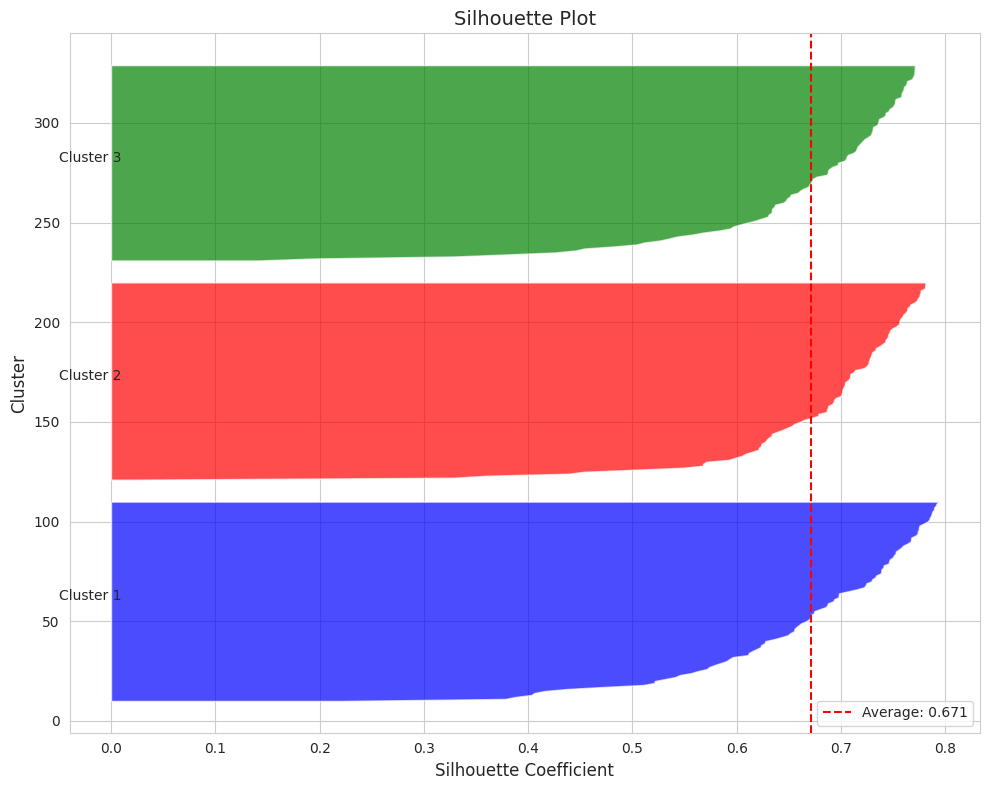

In [11]:
# Silhouette plot
fig, ax = plt.subplots(figsize=(10, 8))

y_lower = 10
for k in range(3):
    # Get silhouette values for cluster k
    cluster_silhouette = silhouette_vals[y_kmeans == k]
    cluster_silhouette.sort()
    
    size_cluster = len(cluster_silhouette)
    y_upper = y_lower + size_cluster
    
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette,
                     facecolor=colors[k], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster, f'Cluster {k+1}')
    
    y_lower = y_upper + 10

ax.axvline(x=silhouette_avg, color='red', linestyle='--', 
           label=f'Average: {silhouette_avg:.3f}')
ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_title('Silhouette Plot', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

## 24.5 クラスター数の選択

### エルボー法
WCSS（クラスター内平方和）の変化率が急激に減少する点を選択

### シルエット法
平均シルエット係数が最大となるクラスター数を選択

### ギャップ統計量
$$\text{Gap}_n(k) = E_n^*[\log W_k] - \log W_k$$

一様分布からの期待値と実際の値の差を最大化

クラスター数の選択


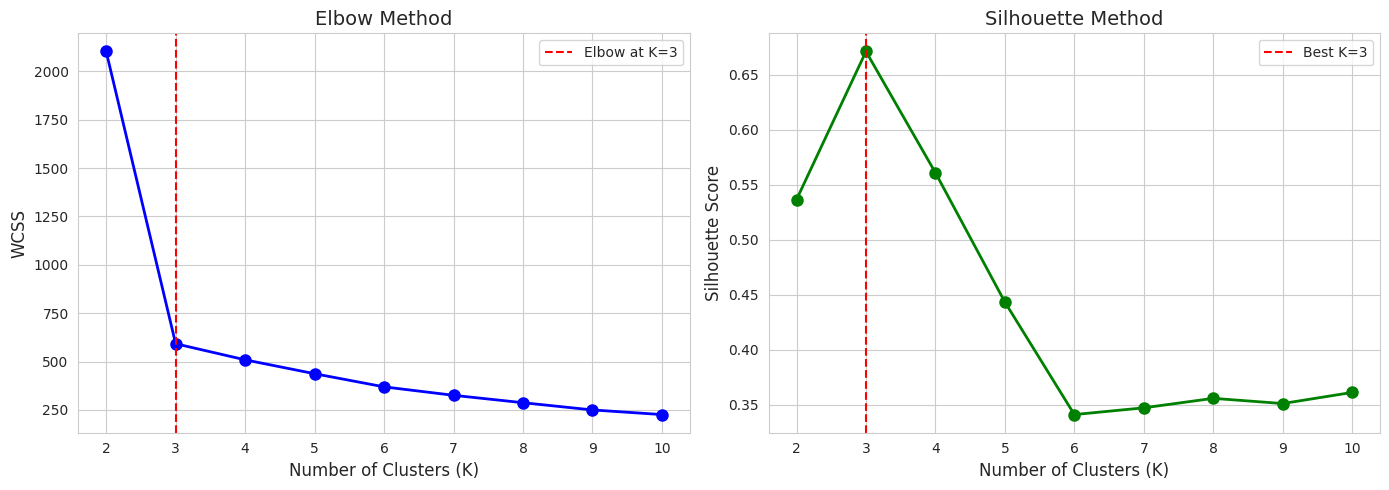


最適クラスター数:
  エルボー法: K = 3 (視覚的判断)
  シルエット法: K = 3


In [12]:
# クラスター数の選択
print("クラスター数の選択")
print("="*60)

K_range = range(2, 11)
wcss = []
silhouettes = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    
    if k > 1:
        silhouettes.append(silhouette_score(X, kmeans.labels_))
    else:
        silhouettes.append(0)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow method
axes[0].plot(K_range, wcss, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('WCSS', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14)
axes[0].axvline(3, color='red', linestyle='--', label='Elbow at K=3')
axes[0].legend()

# Silhouette method
axes[1].plot(K_range, silhouettes, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Method', fontsize=14)
best_k = K_range[np.argmax(silhouettes)]
axes[1].axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n最適クラスター数:")
print(f"  エルボー法: K = 3 (視覚的判断)")
print(f"  シルエット法: K = {best_k}")

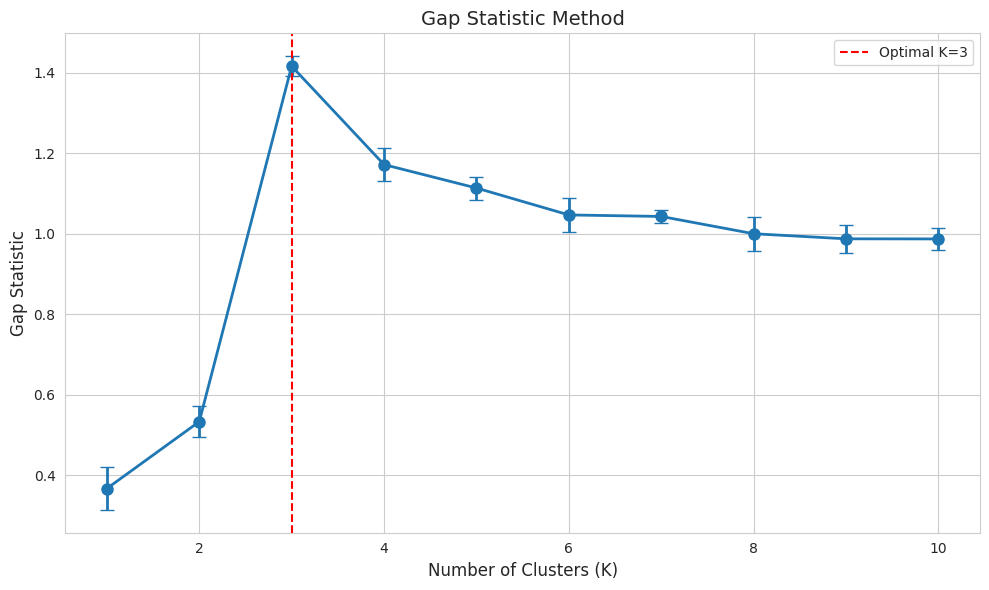

In [13]:
# Gap statistic (simplified version)
def compute_gap_statistic(X, K_max, n_refs=10):
    """Compute gap statistic for cluster number selection."""
    gaps = []
    s_k = []
    
    for k in range(1, K_max + 1):
        # Cluster original data
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)
        log_wk = np.log(kmeans.inertia_)
        
        # Generate reference data
        ref_inertias = []
        for _ in range(n_refs):
            # Uniform distribution over bounding box
            ref_data = np.random.uniform(
                low=X.min(axis=0), 
                high=X.max(axis=0), 
                size=X.shape
            )
            kmeans_ref = KMeans(n_clusters=k, random_state=42, n_init=10)
            kmeans_ref.fit(ref_data)
            ref_inertias.append(np.log(kmeans_ref.inertia_))
        
        # Gap statistic
        gap = np.mean(ref_inertias) - log_wk
        gaps.append(gap)
        s_k.append(np.std(ref_inertias) * np.sqrt(1 + 1/n_refs))
    
    return np.array(gaps), np.array(s_k)

# Compute gap statistic
gaps, s_k = compute_gap_statistic(X, 10, n_refs=10)

# Find optimal K (first K where Gap(k) >= Gap(k+1) - s_{k+1})
optimal_k = 1
for k in range(len(gaps) - 1):
    if gaps[k] >= gaps[k+1] - s_k[k+1]:
        optimal_k = k + 1
        break

fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(range(1, 11), gaps, yerr=s_k, fmt='o-', linewidth=2, markersize=8, capsize=5)
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('Gap Statistic', fontsize=12)
ax.set_title('Gap Statistic Method', fontsize=14)
ax.axvline(optimal_k, color='red', linestyle='--', label=f'Optimal K={optimal_k}')
ax.legend()
plt.tight_layout()
plt.show()

## 24.6 距離と類似度

### ユークリッド距離
$$d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{j=1}^{p}(x_j - y_j)^2}$$

### マンハッタン距離
$$d(\mathbf{x}, \mathbf{y}) = \sum_{j=1}^{p}|x_j - y_j|$$

### コサイン類似度
$$\text{similarity}(\mathbf{x}, \mathbf{y}) = \frac{\mathbf{x} \cdot \mathbf{y}}{||\mathbf{x}|| \cdot ||\mathbf{y}||}$$

In [14]:
# 距離の比較
print("距離尺度の比較")
print("="*60)

# Sample points
a = np.array([0, 0])
b = np.array([3, 4])

# Euclidean distance
euclidean = np.sqrt(np.sum((a - b)**2))

# Manhattan distance
manhattan = np.sum(np.abs(a - b))

# Cosine distance
if np.linalg.norm(a) > 0 and np.linalg.norm(b) > 0:
    cosine_sim = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
else:
    cosine_sim = 0

print(f"\n点A: {a}")
print(f"点B: {b}")
print(f"\nユークリッド距離: {euclidean:.3f}")
print(f"マンハッタン距離: {manhattan:.3f}")
print(f"コサイン類似度: {cosine_sim:.3f}")

距離尺度の比較

点A: [0 0]
点B: [3 4]

ユークリッド距離: 5.000
マンハッタン距離: 7.000
コサイン類似度: 0.000


## 24.7 練習問題

### 問題1
K-meansアルゴリズムの初期値依存性について説明し、対策を述べよ。

### 問題2
階層的クラスタリングにおける各結合法（単連結、完全連結、ウォード法）の特徴を比較せよ。

### 問題3
以下のデータに対してK-means（K=2）を適用し、シルエット係数を計算せよ。

In [15]:
# 問題1の解答
print("問題1: K-meansの初期値依存性")
print("="*60)

print("""
【初期値依存性の問題】
- K-meansは局所最適解に収束
- 初期値によって異なる解が得られる
- 悪い初期値では質の低いクラスタリング結果

【対策】
1. 複数回実行 (n_init パラメータ)
   - 異なる初期値で複数回実行
   - WCSSが最小の結果を採用

2. K-means++ 初期化
   - 最初の中心をランダムに選択
   - 2番目以降は既存中心から遠い点を高確率で選択
   - 良い初期配置が得られやすい

3. 階層的クラスタリングの結果を利用
   - 階層的クラスタリングの中心を初期値として使用
""")

問題1: K-meansの初期値依存性

【初期値依存性の問題】
- K-meansは局所最適解に収束
- 初期値によって異なる解が得られる
- 悪い初期値では質の低いクラスタリング結果

【対策】
1. 複数回実行 (n_init パラメータ)
   - 異なる初期値で複数回実行
   - WCSSが最小の結果を採用

2. K-means++ 初期化
   - 最初の中心をランダムに選択
   - 2番目以降は既存中心から遠い点を高確率で選択
   - 良い初期配置が得られやすい

3. 階層的クラスタリングの結果を利用
   - 階層的クラスタリングの中心を初期値として使用



In [16]:
# 問題2の解答
print("問題2: 結合法の比較")
print("="*60)

print("""
【単連結法 (Single Linkage)】
- クラスター間の最小距離
- 長く伸びた鎖状のクラスターを形成しやすい
- 外れ値に敏感
- 密度の異なるクラスターに適する

【完全連結法 (Complete Linkage)】
- クラスター間の最大距離
- コンパクトなクラスターを形成
- 外れ値に頑健
- クラスターサイズが均等になりやすい

【ウォード法 (Ward's Method)】
- クラスター内分散の増加を最小化
- 球状で同程度のサイズのクラスター
- 最もよく使われる方法
- K-meansと同様の仮定
""")

問題2: 結合法の比較

【単連結法 (Single Linkage)】
- クラスター間の最小距離
- 長く伸びた鎖状のクラスターを形成しやすい
- 外れ値に敏感
- 密度の異なるクラスターに適する

【完全連結法 (Complete Linkage)】
- クラスター間の最大距離
- コンパクトなクラスターを形成
- 外れ値に頑健
- クラスターサイズが均等になりやすい

【ウォード法 (Ward's Method)】
- クラスター内分散の増加を最小化
- 球状で同程度のサイズのクラスター
- 最もよく使われる方法
- K-meansと同様の仮定



問題3: K-meansとシルエット係数

K-means (K=2) 結果:
中心1: [ 0.0931192  -0.07934794]
中心2: [ 5.17586428 -0.21220141]

シルエット係数: 0.645


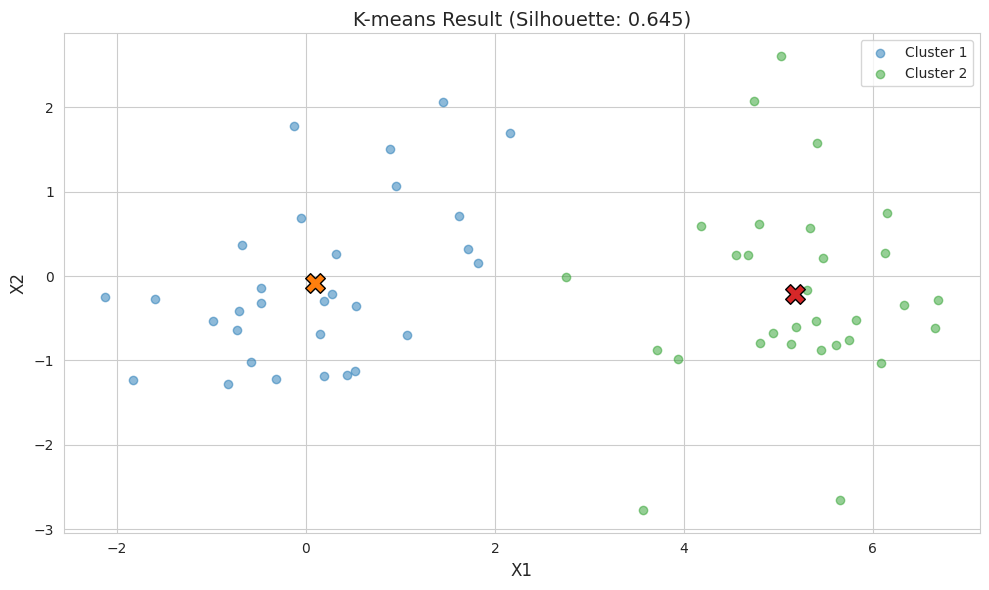

In [17]:
# 問題3の解答
print("問題3: K-meansとシルエット係数")
print("="*60)

# Generate sample data
np.random.seed(333)
X_prob = np.vstack([
    np.random.randn(30, 2) + [0, 0],
    np.random.randn(30, 2) + [5, 0]
])

# K-means with K=2
kmeans_prob = KMeans(n_clusters=2, random_state=42)
labels_prob = kmeans_prob.fit_predict(X_prob)

# Silhouette score
sil_score = silhouette_score(X_prob, labels_prob)

print(f"\nK-means (K=2) 結果:")
print(f"中心1: {kmeans_prob.cluster_centers_[0]}")
print(f"中心2: {kmeans_prob.cluster_centers_[1]}")
print(f"\nシルエット係数: {sil_score:.3f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
for k in range(2):
    mask = labels_prob == k
    ax.scatter(X_prob[mask, 0], X_prob[mask, 1], alpha=0.5, label=f'Cluster {k+1}')
    ax.scatter(*kmeans_prob.cluster_centers_[k], s=200, marker='X', edgecolor='black')

ax.set_xlabel('X1', fontsize=12)
ax.set_ylabel('X2', fontsize=12)
ax.set_title(f'K-means Result (Silhouette: {sil_score:.3f})', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

## ⚠️ よくある間違いと解決策

統計分析では、手法の前提条件を確認せずに適用してしまうことがよくあります。必ず前提を確認し、適切な手法を選択しましょう。

---

## 📝 理解度チェック

この章で学んだ内容を振り返り、重要な概念を自分の言葉で説明できるか確認しましょう。

---

## 📚 まとめ

お疲れ様でした！この章で学んだ手法は、実際のデータ分析で頻繁に使われます。実データで試して理解を深めましょう。

---